In [1]:
# To Do

# figure out how to add primaries
# figure out how to test Pmp dep
# test Pmp dep
# figure out why I can't have A_s, n_s
# figure out how free A should be
# compute constraints for a few different cosmologies, compare to old constraints

## Setup                                                                              

In [2]:
# import tools

# standard library
import glob
import re
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp
import datetime

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline, interp1d
from scipy.optimize import curve_fit
import pandas as pd

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown, HTML
from tabulate import tabulate

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
from cobaya_utilities import fisher
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples
from getdist.gaussian_mixtures import GaussianND

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [3]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import build_data_vector
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import project_fisher_matrix
from functions_and_classes import get_partial_derivative
from functions_and_classes import sample_fisher_with_uniform_priors
from functions_and_classes import plot_Fisher_from_matrices
from functions_and_classes import load_txt_fisher_matrices
from functions_and_classes import analyze_fisher_matrices
from functions_and_classes import plot_fisher_diagnostics
from functions_and_classes import plot_cobaya_mcmc_results
from functions_and_classes import get_ell_bin_edges

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import FisherForecaster
from functions_and_classes import LRFisherForecaster

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [4]:
# cosmologies and priors -- all values from DESI DR2 Chains, DESI+CMB or, if available, DESI+CMB+DESY5

# flat LCDM
# values taken from Planck 2018 TT, TE, EE+lowE
Omega_b = 0.04807
Omega_c = 0.2532
Omega_k = 0
w0 = -1
wa = 0
h = 0.6817
n_s = 0.9693
A_s = 2.122e-9
ln1010A_s = 3.05494413319
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved LCDM
Omega_b = 0.04735
Omega_c = 0.2547
Omega_k = 0.00231
w0 = -1
wa = 0
h = 0.6850
n_s = 0.9649
A_s = 2.115e-9
ln1010A_s = 3.0516399054
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# flat wCDM
Omega_b = 0.04929
Omega_c = 0.2591
Omega_k = 0
w0 = -0.9706
wa = 0
h = 0.6734
n_s = 0.9699
A_s = 2.127e-9
ln1010A_s = 3.05729762921
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_wCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})


# flat w0wa
Omega_b = 0.04991
Omega_c = 0.2676
Omega_k = 0
w0 = -0.7521
wa = -0.8611
h = 0.6674
n_s = 0.9654
A_s = 2.094e-9
ln1010A_s = 3.04166120544
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved w0wa
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# define prior
# all priors taken from Planck unless otherwise stated (https://arxiv.org/pdf/1303.5076)
uniform_prior = {
    'Omega_c': (0.1, 0.9), # not Planck prior given, prior self chosen
    'wa': (-3, 3),         # wider than Planck prior by 1 in each direction
    'w0': (-3, -0.3),
    'A_s': (1.48797e-9, 5.45981e-9),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221),
    'n_s': (0.9, 1.1),
    'Omega_k': (-0.3, 0.3),
    'm_nu': (0, 5)
}

## Data and Noise

In [5]:
# DESI DES sky overlap: https://watermark02.silverchair.com/stad2221.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAAA1UwggNRBgkqhkiG9w0BBwagggNCMIIDPgIBADCCAzcGCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMPF_1Rf3PlLw4g5VBAgEQgIIDCIlykzq-IzVjb7Q-kkK-E_5umppOPSrMHOM4UcfgCovcPTCkOTtlNtDEuRTFA8zh7iBGNGsDnd-8gGRpt2fMeYXMDfYdJol0EmAVU0jzC3QS09cUU7bsCWObaMC30q1RllRRoW2tDw7GSidmi6o3q16CC17S3E0jNNYCsN4V1_glxcQLPsOMlNPPvndES-6O6fcMLjmBkTVj5Lqxhp46NfXfdxchfyI0u2lk7KpnQr8MQ7TNZszs8sIL9ksFU-OatEjM9dTdQYZeatWHf8i2By5iBsjDC3kcJgunHdU486xBXXUNLxwte63Ri_ZH5L0Nc5wNxgVP4PueqeUZiVIE_Ws-V_QlzbzWRH5vQ_AczOlvpZCSBNyPdxQ0i0aSXEssjBTePJbpJ744tQgyw9rPheWDeEC-RzSx9thKoGpWl_39VNZkGlcO5WEA-u8S_dzA9B7b55qQnwpHHNX8NS_7zU8s17pbPJfnz7CoTVteiRR9kDfR3IthFsL92-mHtdzDb810c8T3JImSFRGEiUDaMNWjqgcIPWT38wjMZiR_p95oQ897WCLJmD88Ychm-PjGxtNSNU70f9495aOJ4ObOUvEi8gn_ZS6yosWd1bxdHkqgn1KTXY4dii7IuKHmnffcLiAVOytkEe0RuOdLmSsaKfX8HshbaKKrpsmXPcWar3anMykqxkPKvqQxCUVo9wDJq3SDd6evAfr0nBGBZo1bHepZ43VTJzi-2KLhHG2teDw_8yFLOU0lHDgJEYoTfpDvtLHhAklEUd5V4XmjIwN4KcDNt2CJoun9y_zmH-8pdP4Oc5h_XYcTBuvNa7lKYbh2js_SMwANW1cjrv2LeS7eqoLljb1XqsrgxowX61urarvsn2NX-xy2ctqiH0Wjvl3IS88_zzJ_kEdd46dztq6PXNWdpWeImvc_PD2G46eUMQUhOa69a2v1kL_BpCl4WUBQRifU7x3O7SSTyfyOIislu2aDkc-xnAwvdBYL2SFR2kKsXQHC5eELAUm5iVu1_ui6JBTtjeGDj7Jv

In [6]:
# BGS and LRG data

# make arrays
data_dir = "data/dNdz"

bgs1 = np.loadtxt(os.path.join(data_dir, "BGSz1_dNdz.txt"))
bgs2 = np.loadtxt(os.path.join(data_dir, "BGSz2_dNdz.txt"))
BGS_distributions = np.column_stack((bgs1[:, 0], bgs1[:, 1], bgs2[:, 1]))
BGS_distributions_bin1 = np.column_stack((bgs1[:, 0], bgs1[:, 1]))

lrg1 = np.loadtxt(os.path.join(data_dir, "LRGz1_dNdz.txt"))
lrg2 = np.loadtxt(os.path.join(data_dir, "LRGz2_dNdz.txt"))
lrg3 = np.loadtxt(os.path.join(data_dir, "LRGz3_dNdz.txt"))
lrg4 = np.loadtxt(os.path.join(data_dir, "LRGz4_dNdz.txt"))
LRG_distributions = np.column_stack((lrg1[:, 0], lrg1[:, 1], lrg2[:, 1], lrg3[:, 1], lrg4[:, 1]))
LRG_distributions_bin1 = np.column_stack((lrg1[:, 0], lrg1[:, 1]))

# normalize
z_bgs = BGS_distributions[:, 0]

for i in range(1, BGS_distributions.shape[1]):
    area = np.trapezoid(BGS_distributions[:, i], x=z_bgs)
    if area > 0:
        BGS_distributions[:, i] /= area

z_lrg = LRG_distributions[:, 0]

for i in range(1, LRG_distributions.shape[1]):
    area = np.trapezoid(LRG_distributions[:, i], x=z_lrg)
    if area > 0:
        LRG_distributions[:, i] /= area

In [7]:
# BGS and LRG bins on a unified grid

# define a common grid
z_min = min(BGS_distributions[:, 0].min(), LRG_distributions[:, 0].min())
z_max = max(BGS_distributions[:, 0].max(), LRG_distributions[:, 0].max())
z_master = np.arange(z_min, z_max + 0.001, 0.01)

# initialize
BGS_LRG_distributions = np.zeros((len(z_master), 7))
BGS_LRG_distributions[:, 0] = z_master

# interpolate
z_bgs = BGS_distributions[:, 0]
for i in range(1, 3):  # Columns 1, 2
    BGS_LRG_distributions[:, i] = np.interp(
        z_master, z_bgs, BGS_distributions[:, i], left=0.0, right=0.0
    )

z_lrg = LRG_distributions[:, 0]
for i in range(1, 5):  # Columns 1, 2, 3, 4
    BGS_LRG_distributions[:, i + 2] = np.interp(
        z_master, z_lrg, LRG_distributions[:, i], left=0.0, right=0.0
    )

# renormalize
for col in range(1, 7):
    area = np.trapezoid(BGS_LRG_distributions[:, col], x=z_master)
    if area > 0:
        BGS_LRG_distributions[:, col] /= area


# save
data_dir = "data"
np.save(os.path.join(data_dir, "BGS_distributions_bin1.npy"), BGS_distributions_bin1)
np.save(os.path.join(data_dir, "BGS_distributions.npy"), BGS_distributions)
np.save(os.path.join(data_dir, "LRG_distributions_bin1.npy"), LRG_distributions_bin1)
np.save(os.path.join(data_dir, "LRG_distributions.npy"), LRG_distributions)
np.save(os.path.join(data_dir, "BGS_LRG_distributions.npy"), BGS_LRG_distributions)

In [8]:
# HSC and DES source data

# HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

# DES Source Data

DES_source_data = np.loadtxt("data/des_nz_gamma.txt")
DES_source_data = DES_source_data[7:]  # removes the first 7 values (headers)
DES_source_data = DES_source_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DES_source_z    = DES_source_data[:, 0]
DES_source_nz_a = DES_source_data[:, 1]
DES_source_nz_b = DES_source_data[:, 2]
DES_source_nz_c = DES_source_data[:, 3]
DES_source_nz_d = DES_source_data[:, 4]

DES_source_data = np.column_stack((DES_source_z, DES_source_nz_a, DES_source_nz_b, DES_source_nz_c, DES_source_nz_d))

# DES normalization
area_a = np.trapezoid(DES_source_nz_a, x=DES_source_z)
area_b = np.trapezoid(DES_source_nz_b, x=DES_source_z)
area_c = np.trapezoid(DES_source_nz_c, x=DES_source_z)
area_d = np.trapezoid(DES_source_nz_d, x=DES_source_z)

DES_source_nz_a_norm = DES_source_nz_a / area_a
DES_source_nz_b_norm = DES_source_nz_b / area_b
DES_source_nz_c_norm = DES_source_nz_c / area_c
DES_source_nz_d_norm = DES_source_nz_d / area_d

DES_source_data = np.column_stack((DES_source_z, DES_source_nz_a_norm, DES_source_nz_b_norm, DES_source_nz_c_norm, DES_source_nz_d_norm))
DES_source_data_bin1 = np.column_stack((DES_source_z, DES_source_nz_a_norm))
des_bins_norm = [DES_source_nz_a_norm, DES_source_nz_b_norm, DES_source_nz_c_norm, DES_source_nz_d_norm]

# save
data_dir = "data"
np.save(os.path.join(data_dir, "DES_source_data.npy"), DES_source_data)
np.save(os.path.join(data_dir, "DES_source_data_bin1.npy"), DES_source_data_bin1)
np.save(os.path.join(data_dir, "HSC_source_data.npy"), HSC_dist_0_3)

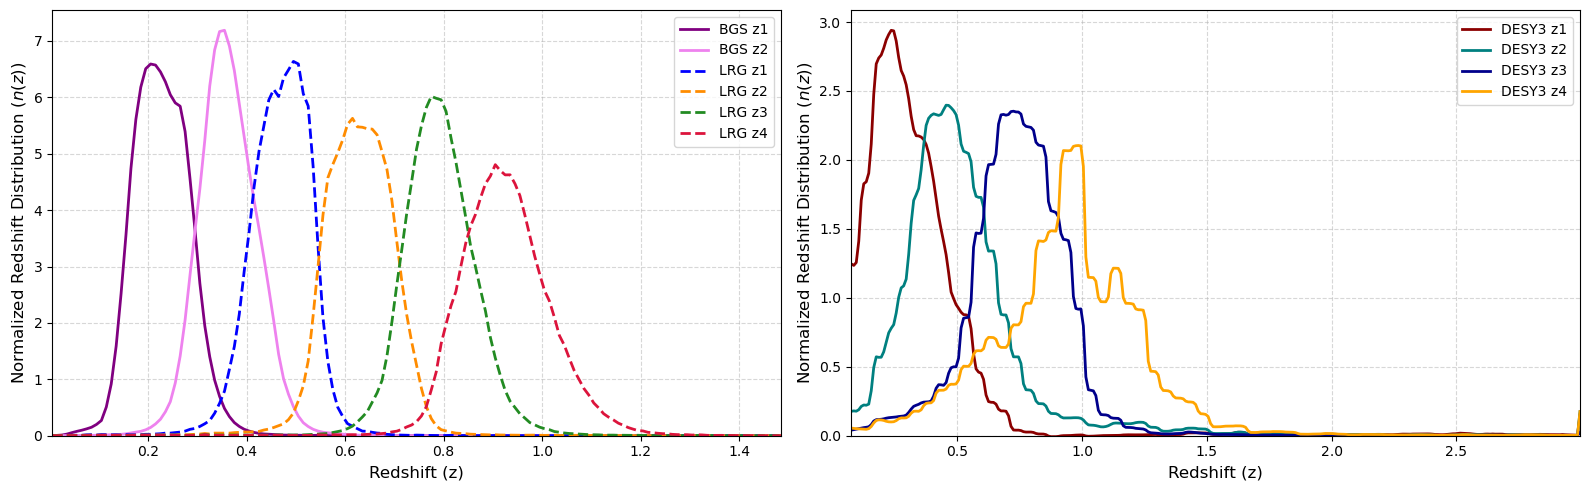

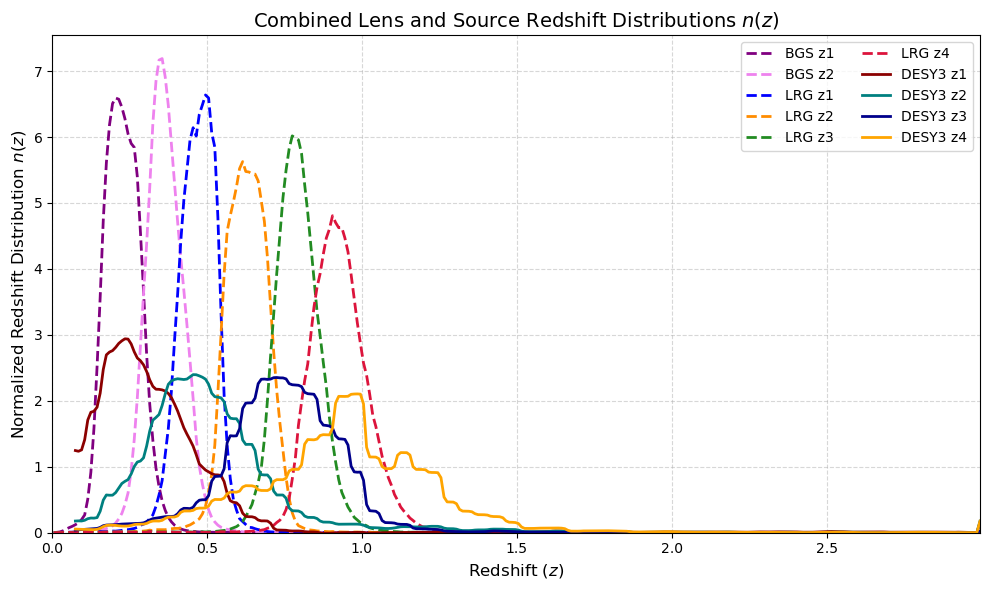

In [9]:
# plot all bins together

des_colors = ["darkred", "teal", "darkblue", "orange"]

# --- Figure setup: 1 row, 2 columns ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# Left Subplot: BGS & LRG Bins
z_master = BGS_LRG_distributions[:, 0]

ax1.plot(
    z_master,
    BGS_LRG_distributions[:, 1],
    label="BGS z1",
    color="purple",
    lw=2,
)
ax1.plot(
    z_master,
    BGS_LRG_distributions[:, 2],
    label="BGS z2",
    color="violet",
    lw=2,
)

lrg_colors = ["blue", "darkorange", "forestgreen", "crimson"]
for i in range(1, 5):
    ax1.plot(
        z_master,
        BGS_LRG_distributions[:, i + 2],
        label=f"LRG z{i}",
        color=lrg_colors[i - 1],
        lw=2,
        linestyle="--",
    )

ax1.set_xlabel("Redshift (z)", fontsize=12)
ax1.set_ylabel("Normalized Redshift Distribution ($n(z)$)", fontsize=12)
ax1.set_xlim(z_master.min(), z_master.max())
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(fontsize=10, loc="upper right", frameon=True)

# Right Subplot: DES Source Bins
for i, (nz_norm, color) in enumerate(zip(des_bins_norm, des_colors), start=1):
    ax2.plot(
        DES_source_z,
        nz_norm,
        label=f"DESY3 z{i}",
        color=color,
        lw=2,
    )

ax2.set_xlabel("Redshift (z)", fontsize=12)
ax2.set_ylabel("Normalized Redshift Distribution ($n(z)$)", fontsize=12)
ax2.set_xlim(DES_source_z.min(), DES_source_z.max())
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(fontsize=10, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

z_master = BGS_LRG_distributions[:, 0]

# --- Lens Bins (BGS & LRG) - Dashed Lines ---
plt.plot(
    z_master,
    BGS_LRG_distributions[:, 1],
    label="BGS z1",
    color="purple",
    lw=2,
    linestyle="--",
)
plt.plot(
    z_master,
    BGS_LRG_distributions[:, 2],
    label="BGS z2",
    color="violet",
    lw=2,
    linestyle="--",
)

lrg_colors = ["blue", "darkorange", "forestgreen", "crimson"]
for i in range(1, 5):
  plt.plot(
      z_master,
      BGS_LRG_distributions[:, i + 2],
      label=f"LRG z{i}",
      color=lrg_colors[i - 1],
      lw=2,
      linestyle="--",
  )

# --- Source Bins (DESY3) - Solid Lines ---
for i, (nz_norm, color) in enumerate(
    zip(des_bins_norm, des_colors), start=1
):
  plt.plot(
      DES_source_z,
      nz_norm,
      label=f"DESY3 z{i}",
      color=color,
      lw=2,
      linestyle="-",
  )

plt.xlabel("Redshift ($z$)", fontsize=12)
plt.ylabel("Normalized Redshift Distribution $n(z)$", fontsize=12)
plt.title(
    "Combined Lens and Source Redshift Distributions $n(z)$", fontsize=14
)
plt.xlim(0, max(z_master.max(), DES_source_z.max()))
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right", frameon=True, ncol=2)

plt.tight_layout()
plt.show()

[1.02326265e-09]


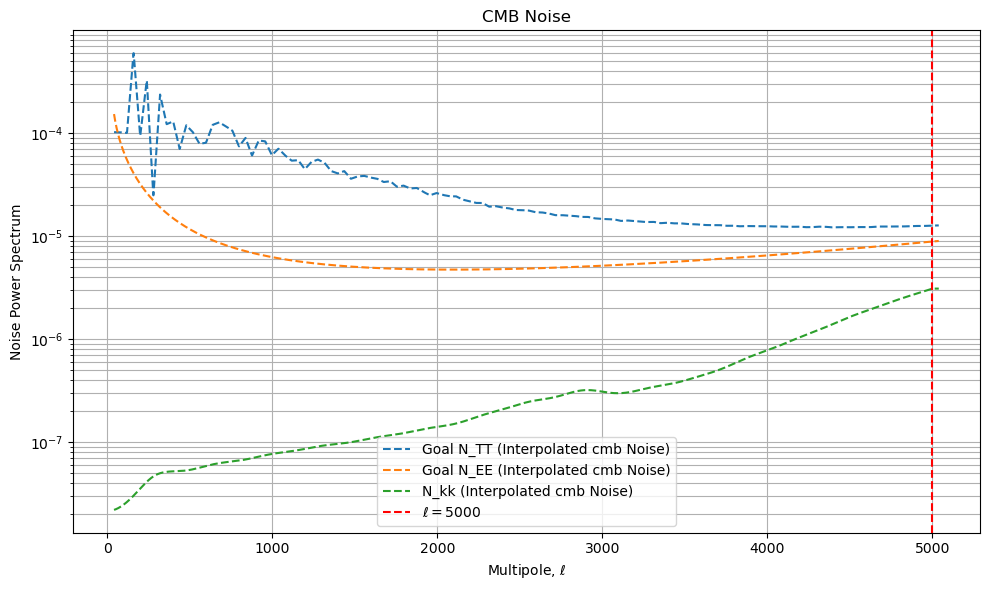

In [10]:
# build noise magnification
# BGS shot noise ref: 
# LRG shot noise ref: https://arxiv.org/pdf/2407.04607
# DES noise ref: https://arxiv.org/html/2511.04681v2
# HSC noise ref: https://arxiv.org/pdf/2507.01386
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
LRG_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree
LRG_n_bar_steradian = LRG_n_bar_deg2 * (180.0 / np.pi)**2
HSC_n_bar_arcmin2 = np.array([3.77, 5.07, 4.00, 2.12])
HSC_n_bar_deg2 = HSC_n_bar_arcmin2 * (60 ** 2)
HSC_n_bar_steradian = HSC_n_bar_deg2 * (180.0 / np.pi)**2
DES_n_bar_arcmin2 = np.array([5.59, 5.59, 5.59, 5.59])
DES_n_bar_deg2 = DES_n_bar_arcmin2 * (60 ** 2)
DES_n_bar_steradian = DES_n_bar_deg2 * (180.0 / np.pi)**2
BGS_shot_noise = [4.63e-7, 9.18e-7]
BGS_shot_noise_bin1 = [4.63e-7]
LRG_shot_noise = [4.07e-6, 2.25e-6, 2.05e-6, 2.25e-6]
LRG_shot_noise_bin1 = [4.07e-6]
BGS_LRG_shot_noise = [4.63e-7, 9.18e-7, 4.07e-6, 2.25e-6, 2.05e-6, 2.25e-6]

HSC_shape_noise = np.zeros_like(HSC_n_bar_steradian)
for i in range(len(HSC_shape_noise)):
    HSC_shape_noise[i] = sigma ** 2 / HSC_n_bar_steradian[i]

DES_shape_noise = np.zeros_like(DES_n_bar_steradian)
for i in range(len(DES_shape_noise)):
    DES_shape_noise[i] = sigma ** 2 / DES_n_bar_steradian[i]
DES_shape_noise_bin1 = np.array([DES_shape_noise[0]])
print(DES_shape_noise_bin1)

# cmb noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_goal_T_noise_data = np.loadtxt("data/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt")
SO_goal_T_noise_ells = SO_goal_T_noise_data[:, 0]
SO_goal_N_TT = SO_goal_T_noise_data[:, 1]
SO_goal_E_noise_data = np.loadtxt("data/SO_LAT_Nell_P_goal_fsky0p4_ILC_CMB_E.txt")
SO_goal_E_noise_ells = SO_goal_E_noise_data[:, 0]
SO_goal_N_EE = SO_goal_E_noise_data[:, 1]
SO_kk_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
SO_kk_noise_ells = SO_kk_noise_data[:, 0]
SO_N_kk = SO_kk_noise_data[:, 7]
ells_for_noise_interp = np.arange(40, 5000 + 40)
min1000_ells_for_noise_interp = np.arange(1000, 4000 + 1000)
min2000_ells_for_noise_interp = np.arange(2000, 3000 + 2000)
max2040_ells_for_noise_interp = np.arange(40, 2040)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_goal_N_TT_func = interp1d(SO_goal_T_noise_ells, SO_goal_N_TT, bounds_error=False, fill_value=(SO_goal_N_TT[0], SO_goal_N_TT[-1]))
SO_goal_cmb_noise_TT = interpolated_goal_N_TT_func(ells_for_noise_interp)
interpolated_goal_N_EE_func = interp1d(SO_goal_E_noise_ells, SO_goal_N_EE, bounds_error=False, fill_value=(SO_goal_N_EE[0], SO_goal_N_EE[-1]))
SO_goal_cmb_noise_EE = interpolated_goal_N_EE_func(ells_for_noise_interp)
interpolated_N_kk_func = interp1d(SO_kk_noise_ells, SO_N_kk, bounds_error=False, fill_value=(SO_N_kk[0], SO_N_kk[-1]))
SO_cmb_noise_kk = interpolated_N_kk_func(ells_for_noise_interp)
min1000_SO_cmb_noise_kk = interpolated_N_kk_func(min1000_ells_for_noise_interp)
min2000_SO_cmb_noise_kk = interpolated_N_kk_func(min2000_ells_for_noise_interp)
max2040_SO_cmb_noise_kk = interpolated_N_kk_func(max2040_ells_for_noise_interp)

# plot cmb noise to see what it looks like
plt.figure(figsize=(10, 6))
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_TT, label='Goal N_TT (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_EE, label='Goal N_EE (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_cmb_noise_kk, label='N_kk (Interpolated cmb Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum')
plt.title('CMB Noise')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

# save
data_dir = "data"
np.save(os.path.join(data_dir, "BGS_shot_noise.npy"), BGS_shot_noise)
np.save(os.path.join(data_dir, "BGS_shot_noise_bin1.npy"), BGS_shot_noise_bin1)
np.save(os.path.join(data_dir, "LRG_shot_noise.npy"), LRG_shot_noise)
np.save(os.path.join(data_dir, "LRG_shot_noise_bin1.npy"), LRG_shot_noise_bin1)
np.save(os.path.join(data_dir, "BGS_LRG_shot_noise.npy"), BGS_LRG_shot_noise)
np.save(os.path.join(data_dir, "HSC_shape_noise.npy"), HSC_shape_noise)
np.save(os.path.join(data_dir, "DES_shape_noise.npy"), DES_shape_noise)
np.save(os.path.join(data_dir, "DES_shape_noise_bin1.npy"), DES_shape_noise_bin1)
np.save(os.path.join(data_dir, "SO_goal_cmb_noise_TT.npy"), SO_goal_cmb_noise_TT)
np.save(os.path.join(data_dir, "SO_goal_cmb_noise_EE.npy"), SO_goal_cmb_noise_EE)
np.save(os.path.join(data_dir, "SO_cmb_noise_kk.npy"), SO_cmb_noise_kk)

# LRFisher

In [11]:
recommended_h = {
    "Omega_c": 1.420e-03,
    "A_s": 3.954e-13,
    "h": 2.577e-03,
    "w0": 3.445e-03,
    "wa": 5.428e-04,
    "n_s": 2.133e-04,
    "Omega_b": 4.594e-05,
    "Omega_k": 4.080e-06,
}

In [ ]:
# %% [1] Build the fiducial cosmology -- same pattern as your existing FisherForecaster call
import pyccl as ccl
import numpy as np

Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
Neff = 3.046  # SM prediction
m_nu = 0.06
T_CMB = 2.7255

camb_extra = {
    "dark_energy_model": "ppf",
    "AccuracyBoost": 3,
    "halofit_version": "mead2020_feedback",
    "HMCode_logT_AGN": 7.8,
}

wrong_camb_extra = {
    "dark_energy_model": "ppf",
    "AccuracyBoost": 3,
    "halofit_version": "mead2020_feedback",
    "HMCode_logT_AGN": 8.2,
}

fiducial_cosmology = ccl.Cosmology(
    Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s,
    w0=w0, wa=wa, T_CMB=T_CMB, Neff=Neff, m_nu=m_nu,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',   # matches _make_cosmo's hmcode branch
    extra_parameters={"camb": camb_extra},
)

wrong_pmm_cosmology = ccl.Cosmology(
    Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s,
    w0=w0, wa=wa, T_CMB=T_CMB, Neff=Neff, m_nu=m_nu,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',   # matches _make_cosmo's hmcode branch
    extra_parameters={"camb": wrong_camb_extra},
)

# %% [2] Build the LRFisherForecaster
#
# desired_spectra only controls what ends up in the final data/model vector --
# everything (GG, CC, LL, CL, etc.) gets computed internally regardless, so
# the covariance blocks for CG/GL are built correctly even though those other
# spectra never appear as rows here. Just list what you actually want fit.

lr = LRFisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=BGS_distributions_bin1,     # swap in a multi-column array if you have >1 lens bin
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min=40,
    n_ell=5000,
    f_sky_c=0.4,
    f_sky_g=0.4,
    f_sky_l=0.1,
    f_sky_c_g=0.295,
    f_sky_c_l=0.0306,
    f_sky_g_l=0.0306,
    f_sky_c_g_l=0.0306,
    magnification_bias_lenses=0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['GL', 'CG'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
    step_dict=recommended_h,
    baryon_feedback_model='hmcode',
    log10_T_AGN=7.8,
    # --- LR-specific kwargs ---
    lens_to_source_bin={1: 1},   # lens bin i -> source bin j; add entries if you add lens bins
    geo_params=['Omega_k', 'w0', 'wa'],      # or e.g. ['w0', 'wa'] with Omega_m/Omega_k fixed
    fiducial_pmm_cosmology=None,  # defaults to `fiducial_cosmology` above
)


# %% [4] The actual Fisher forecast on theta_geo
F_lr, geo_cov = lr.make_lr_fisher_matrix(print_summary=True)

#best_fid, best_wrong, sigma = lr.test_pmm_immunity(lr, wrong_pmm_cosmology)

In [ ]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
Neff = 3.046  # SM prediction
m_nu = 0.06
T_CMB = 2.7255

camb_extra = {
    "dark_energy_model": "ppf",
    "AccuracyBoost": 3,
    "halofit_version": "mead2020_feedback",
    "HMCode_logT_AGN": 7.8,
}

wrong_camb_extra = {
    "dark_energy_model": "ppf",
    "AccuracyBoost": 3,
    "halofit_version": "mead2020_feedback",
    "HMCode_logT_AGN": 8.2,
}

fiducial_cosmology = ccl.Cosmology(
    Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s,
    w0=w0, wa=wa, T_CMB=T_CMB, Neff=Neff, m_nu=m_nu,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',   # matches _make_cosmo's hmcode branch
    extra_parameters={"camb": camb_extra},
)

wrong_pmm_cosmology = ccl.Cosmology(
    Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s,
    w0=w0, wa=wa, T_CMB=T_CMB, Neff=Neff, m_nu=m_nu,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',   # matches _make_cosmo's hmcode branch
    extra_parameters={"camb": wrong_camb_extra},
)

# %% [2] Build the LRFisherForecaster
#
# desired_spectra only controls what ends up in the final data/model vector --
# everything (GG, CC, LL, CL, etc.) gets computed internally regardless, so
# the covariance blocks for CG/GL are built correctly even though those other
# spectra never appear as rows here. Just list what you actually want fit.

lr = LRFisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=BGS_distributions_bin1,     # swap in a multi-column array if you have >1 lens bin
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min=40,
    n_ell=5000,
    f_sky_c=0.4,
    f_sky_g=0.4,
    f_sky_l=0.1,
    f_sky_c_g=0.295,
    f_sky_c_l=0.0306,
    f_sky_g_l=0.0306,
    f_sky_c_g_l=0.0306,
    magnification_bias_lenses=0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['GL', 'CG'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
    step_dict=recommended_h,
    baryon_feedback_model='hmcode',
    log10_T_AGN=7.8,
    # --- LR-specific kwargs ---
    lens_to_source_bin={1: 1},   # lens bin i -> source bin j; add entries if you add lens bins
    geo_params=['Omega_k', 'w0', 'wa', 'Omega_b', 'Omega_c', 'h'],      # or e.g. ['w0', 'wa'] with Omega_m/Omega_k fixed
    fiducial_pmm_cosmology=None,  # defaults to `fiducial_cosmology` above
)


# %% [4] The actual Fisher forecast on theta_geo
F_lr, geo_cov = lr.make_lr_fisher_matrix(print_summary=True)

best_fid, best_wrong, sigma = lr.test_pmm_immunity(lr, wrong_pmm_cosmology)

In [19]:
# %% [1] Build the fiducial cosmology -- same pattern as your existing FisherForecaster call
import pyccl as ccl
import numpy as np

Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
Neff = 3.046  # SM prediction
m_nu = 0.06
T_CMB = 2.7255

camb_extra = {
    "dark_energy_model": "ppf",
    "AccuracyBoost": 3,
    "halofit_version": "mead2020_feedback",
    "HMCode_logT_AGN": 7.8,
}

wrong_camb_extra = {
    "dark_energy_model": "ppf",
    "AccuracyBoost": 3,
    "halofit_version": "mead2020_feedback",
    "HMCode_logT_AGN": 8.2,
}

fiducial_cosmology = ccl.Cosmology(
    Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s,
    w0=w0, wa=wa, T_CMB=T_CMB, Neff=Neff, m_nu=m_nu,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',   # matches _make_cosmo's hmcode branch
    extra_parameters={"camb": camb_extra},
)

wrong_pmm_cosmology = ccl.Cosmology(
    Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s,
    w0=w0, wa=wa, T_CMB=T_CMB, Neff=Neff, m_nu=m_nu,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',   # matches _make_cosmo's hmcode branch
    extra_parameters={"camb": wrong_camb_extra},
)

# %% [2] Build the LRFisherForecaster
#
# desired_spectra only controls what ends up in the final data/model vector --
# everything (GG, CC, LL, CL, etc.) gets computed internally regardless, so
# the covariance blocks for CG/GL are built correctly even though those other
# spectra never appear as rows here. Just list what you actually want fit.

lr = LRFisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=BGS_LRG_distributions,     # swap in a multi-column array if you have >1 lens bin
    source_data=DES_source_data,
    binsize=100,
    logarithmic=False,
    l_min=40,
    n_ell=5000,
    f_sky_c=0.4,
    f_sky_g=0.4,
    f_sky_l=0.1,
    f_sky_c_g=0.295,
    f_sky_c_l=0.0306,
    f_sky_g_l=0.0306,
    f_sky_c_g_l=0.0306,
    magnification_bias_lenses=0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['GL', 'CG'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
    step_dict=recommended_h,
    baryon_feedback_model='hmcode',
    log10_T_AGN=7.8,
    
    # --- LR-specific kwargs ---
    # generally chose lens to source bin to avoid significant lens-source overlap, and ofc to avoid sources that are before the lenses
    lens_to_source_bin = {1: [2, 3, 4], 2: [3, 4], 3: [3, 4], 4: 4, 5: 4},
    geo_params=['Omega_k', 'w0', 'wa', 'Omega_b', 'Omega_c'],      # or e.g. ['w0', 'wa'] with Omega_m/Omega_k fixed
    fiducial_pmm_cosmology=None,  # defaults to `fiducial_cosmology` above
)


# %% [4] The actual Fisher forecast on theta_geo
F_lr, geo_cov = lr.make_lr_fisher_matrix(print_summary=True)


LR Fisher forecast (250 free amplitudes, 450 GL constraints, marginalized)
  sigma(Omega_k) = 2.2816e-03
  sigma(w0) = nan
  sigma(wa) = 1.0645e-01
  sigma(Omega_b) = 9.9502e-03
  sigma(Omega_c) = 3.2107e-02


In [16]:
# %% [1] Build the fiducial cosmology -- same pattern as your existing FisherForecaster call
import pyccl as ccl
import numpy as np

Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
Neff = 3.046  # SM prediction
m_nu = 0.06
T_CMB = 2.7255

camb_extra = {
    "dark_energy_model": "ppf",
    "AccuracyBoost": 3,
    "halofit_version": "mead2020_feedback",
    "HMCode_logT_AGN": 7.8,
}

fiducial_cosmology = ccl.Cosmology(
    Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s,
    w0=w0, wa=wa, T_CMB=T_CMB, Neff=Neff, m_nu=m_nu,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',   # matches _make_cosmo's hmcode branch
    extra_parameters={"camb": camb_extra},
)

# %% [2] Build the LRFisherForecaster
#
# desired_spectra only controls what ends up in the final data/model vector --
# everything (GG, CC, LL, CL, etc.) gets computed internally regardless, so
# the covariance blocks for CG/GL are built correctly even though those other
# spectra never appear as rows here. Just list what you actually want fit.

lr = LRFisherForecaster(
    cosmology=fiducial_cosmology,
    lens_data=BGS_LRG_distributions,     # swap in a multi-column array if you have >1 lens bin
    source_data=DES_source_data,
    binsize=100,
    logarithmic=False,
    l_min=40,
    n_ell=5000,
    f_sky_c=0.4,
    f_sky_g=0.4,
    f_sky_l=0.1,
    f_sky_c_g=0.295,
    f_sky_c_l=0.0306,
    f_sky_g_l=0.0306,
    f_sky_c_g_l=0.0306,
    magnification_bias_lenses=0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['GL', 'CG', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict=recommended_h,
    baryon_feedback_model='hmcode',
    log10_T_AGN=7.8,
    
    # --- LR-specific kwargs ---
    lens_to_source_bin = {1: [2, 3, 4], 2: [3, 4], 3: 4, 4: 4, 5: 4},
    geo_params=['Omega_k', 'w0', 'wa', 'Omega_b', 'Omega_c', 'h'],      # or e.g. ['w0', 'wa'] with Omega_m/Omega_k fixed
    fiducial_pmm_cosmology=None,  # defaults to `fiducial_cosmology` above
)

F_joint, param_cov, combined_params = lr.make_joint_fisher_matrix(
    primary_params=['Omega_k', 'w0', 'wa', 'Omega_b', 'Omega_c', 'h'],
    print_summary=True,
)


Joint LR + primaries Fisher forecast (250 amplitudes marginalized, primaries used: [('E', 'E'), ('T', 'T'), ('E', 'T')])
  sigma(Omega_k) = 1.6383e-03
  sigma(w0) = 1.2934e-01
  sigma(wa) = 1.5761e-01
  sigma(Omega_b) = 5.0817e-03
  sigma(Omega_c) = 2.7920e-02
  sigma(h) = 3.4371e-02


# Fisher

## Curved w0waCDM

In [12]:
recommended_h = {
    "Omega_c": 1.420e-03,
    "A_s": 3.954e-13,
    "h": 2.577e-03,
    "w0": 3.445e-03,
    "wa": 5.428e-04,
    "n_s": 2.133e-04,
    "Omega_b": 4.594e-05,
    "Omega_k": 4.080e-06,
}

In [13]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
camb_extra = {"dark_energy_model": "ppf", "AccuracyBoost": 3}
mps = 'camb'
camb_extra['halofit_version'] = 'mead2020_feedback'
camb_extra['HMCode_logT_AGN'] = 7.8

# build cosmology with assumed baryon feedback strength
curved_w0waCDM_cosmology_w_baryons = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', matter_power_spectrum = mps,
                               extra_parameters={"camb": camb_extra})

ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology_w_baryons,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

# make F, cov, given assumed (incorrect) baryon feedback strength
F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = 0.0000e+00  (+0.00σ)
  ΔA_s = 0.0000e+00  (+0.00σ)
  Δh = 0.0000e+00  (+0.00σ)
  Δw0 = 0.0000e+00  (+0.00σ)
  Δwa = 0.0000e+00  (+0.00σ)
  Δn_s = 0.0000e+00  (+0.00σ)
  ΔOmega_b = 0.0000e+00  (+0.00σ)
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = 0.0000e+00  (+0.00σ)
  ΔA_s = 0.0000e+00  (+0.00σ)
  Δh = 0.0000e+00  (+0.00σ)
  Δw0 = 0.0000e+00  (+0.00σ)
  Δwa = 0.0000e+00  (+0.00σ)
  Δn_s = 0.0000e+00  (+0.00σ)
  ΔOmega_b = 0.0000e+00  (+0.00σ)


In [14]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
camb_extra = {"dark_energy_model": "ppf", "AccuracyBoost": 3}
mps = 'camb'
camb_extra['halofit_version'] = 'mead2020_feedback'
camb_extra['HMCode_logT_AGN'] = 7.8

# build cosmology with assumed baryon feedback strength
curved_w0waCDM_cosmology_w_baryons = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', matter_power_spectrum = mps,
                               extra_parameters={"camb": camb_extra})

ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology_w_baryons,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

# make F, cov, given assumed (incorrect) baryon feedback strength
F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = 3.0423e-02  (+0.40σ)  <-- >0.3σ shift
  ΔA_s = -3.0423e-09  (-0.44σ)  <-- >0.3σ shift
  Δh = 3.7920e-01  (+0.40σ)  <-- >0.3σ shift
  Δw0 = 2.3395e-02  (+0.04σ)
  Δwa = -1.5146e-02  (-0.01σ)
  Δn_s = -4.6255e-01  (-0.52σ)  <-- >0.3σ shift
  ΔOmega_b = -4.3896e-02  (-0.32σ)  <-- >0.3σ shift
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = 4.7678e-02  (+0.63σ)  <-- >0.3σ shift
  ΔA_s = 1.6625e-09  (+0.24σ)
  Δh = -3.8745e-01  (-0.41σ)  <-- >0.3σ shift
  Δw0 = -4.7169e-02  (-0.08σ)
  Δwa = 4.4551e-01  (+0.36σ)  <-- >0.3σ shift
  Δn_s = 2.0546e-01  (+0.23σ)
  ΔOmega_b = -1.9052e-02  (-0.14σ)


In [15]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
camb_extra = {"dark_energy_model": "ppf", "AccuracyBoost": 3}
mps = 'camb'
camb_extra['halofit_version'] = 'mead2020_feedback'
camb_extra['HMCode_logT_AGN'] = 7.8

# build cosmology with assumed baryon feedback strength
curved_w0waCDM_cosmology_w_baryons = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', matter_power_spectrum = mps,
                               extra_parameters={"camb": camb_extra})

ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology_w_baryons,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

# make F, cov, given assumed (incorrect) baryon feedback strength
F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.0)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.6)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.000:
  ΔOmega_c = 4.3058e-03  (+0.06σ)
  ΔA_s = -1.1827e-09  (-0.17σ)
  Δh = 1.6759e-01  (+0.18σ)
  Δw0 = 6.4259e-03  (+0.01σ)
  Δwa = -6.3198e-02  (-0.05σ)
  Δn_s = -1.7377e-01  (-0.20σ)
  ΔOmega_b = -1.1932e-02  (-0.09σ)
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.600:
  ΔOmega_c = 1.0900e-02  (+0.14σ)
  ΔA_s = 8.1021e-10  (+0.12σ)
  Δh = -1.5362e-01  (-0.16σ)
  Δw0 = -1.1290e-02  (-0.02σ)
  Δwa = 1.3837e-01  (+0.11σ)
  Δn_s = 1.0958e-01  (+0.12σ)
  ΔOmega_b = -1.1718e-03  (-0.01σ)


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.269\pm 0.057$ | $\Omega_{c} = 0.27^{+0.11}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.268\pm 0.075$ | $\Omega_{c} = 0.27^{+0.15}_{-0.15}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,3.5^{+1.1}_{-1.6}\,\right)\cdot 10^{-9}$ | $A_s = \left(\,3.5^{+1.9}_{-1.8}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,0.2\pm 1.1\,\right)\cdot 10^{-8}$ | $A_s = \left(\,0.2^{+2.1}_{-2.1}\,\right)\cdot 10^{-8}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.63^{+0.24}_{-0.19}$ | $h = 0.63^{+0.35}_{-0.37}$ |
|  | Fisher Forecast (No Priors) | $h = 0.67\pm 0.95$ | $h = 0.7^{+1.9}_{-1.9}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.85^{+0.46}_{-0.24}$ | $w_0 = -0.85^{+0.58}_{-0.71}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.76\pm 0.62$ | $w_0 = -0.8^{+1.2}_{-1.2}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.72\pm 0.79$ | $w_a = -0.7^{+1.5}_{-1.6}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 1.2$ | $w_a = -0.8^{+2.4}_{-2.5}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 1.006^{+0.076}_{-0.046}$ | $n_s = 1.006^{+0.090}_{-0.10}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.96\pm 0.88$ | $n_s = 0.96^{+1.7}_{-1.7}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.055^{+0.018}_{-0.038}$ | $\Omega_{b} = 0.055^{+0.054}_{-0.045}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.05\pm 0.14$ | $\Omega_{b} = 0.05^{+0.27}_{-0.27}$ |
| --- | --- | --- | --- |

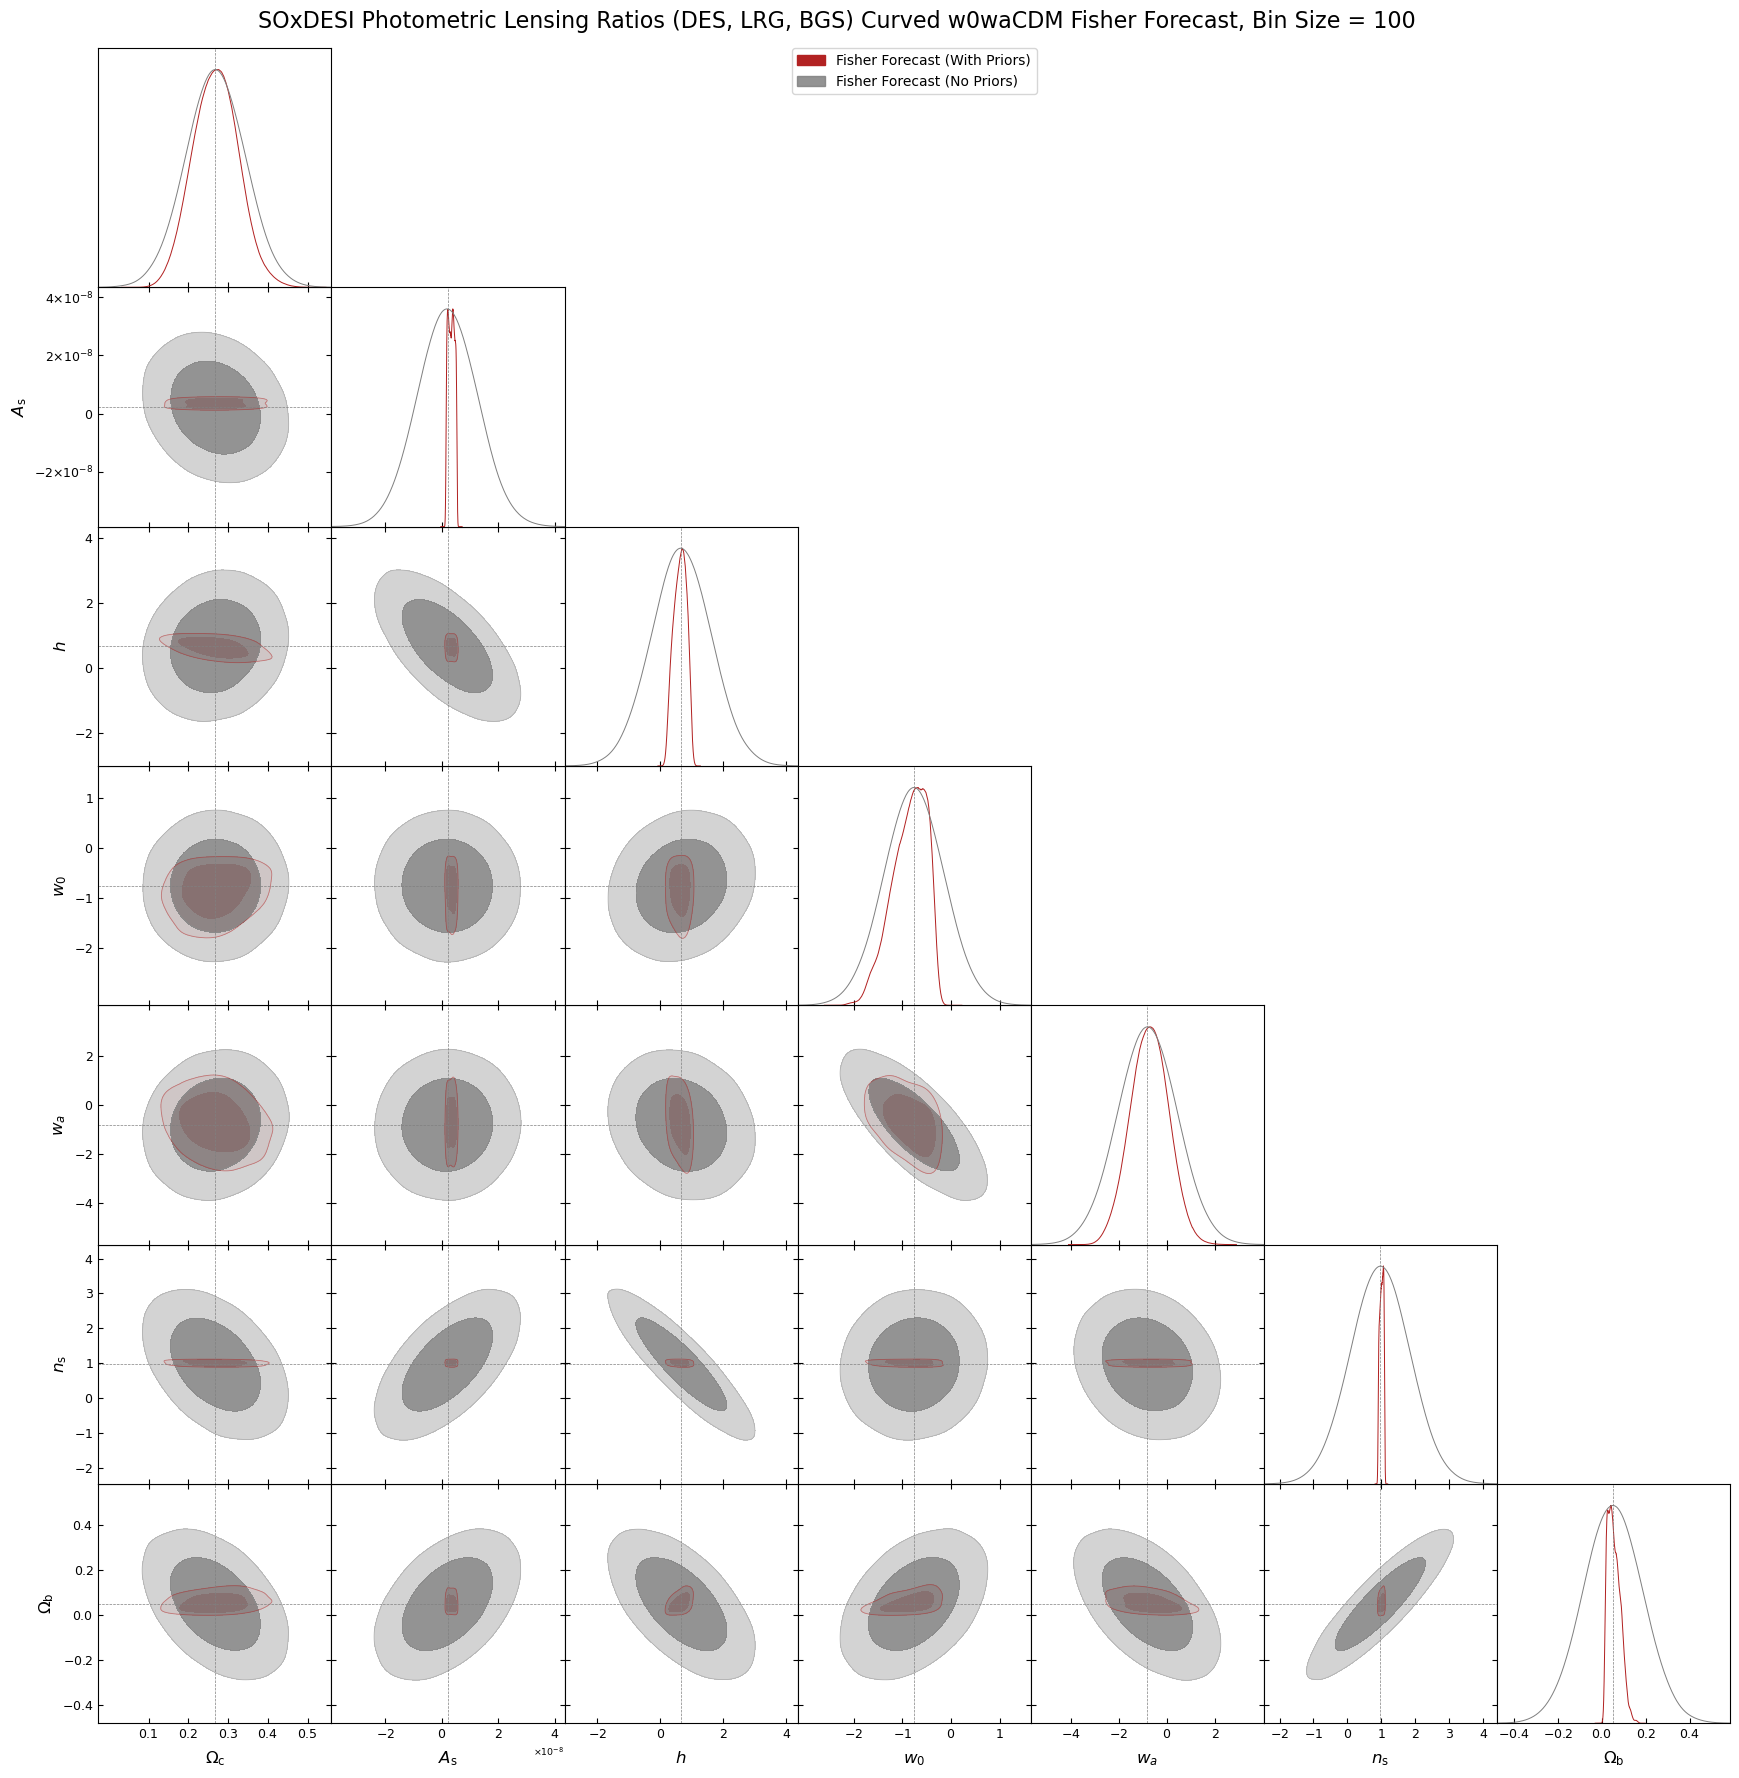

In [16]:
g = ff.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (DES, LRG, BGS) Curved w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'],
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

In [15]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
camb_extra = {"dark_energy_model": "ppf", "AccuracyBoost": 3}
mps = 'camb'
camb_extra['halofit_version'] = 'mead2020_feedback'
camb_extra['HMCode_logT_AGN'] = 7.8

# build cosmology with assumed baryon feedback strength
curved_w0waCDM_cosmology_w_baryons = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', matter_power_spectrum = mps,
                               extra_parameters={"camb": camb_extra})

ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology_w_baryons,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

# make F, cov, given assumed (incorrect) baryon feedback strength
F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.0)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.6)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.000:
  ΔOmega_c = -2.9707e-02  (-0.79σ)  <-- >0.3σ shift
  ΔA_s = -3.6053e-12  (-0.80σ)  <-- >0.3σ shift
  Δh = 3.4302e-02  (+0.75σ)  <-- >0.3σ shift
  Δw0 = -2.0524e-01  (-0.71σ)  <-- >0.3σ shift
  Δwa = 3.7858e-01  (+0.54σ)  <-- >0.3σ shift
  Δn_s = 2.0528e-03  (+0.79σ)  <-- >0.3σ shift
  ΔOmega_b = -5.0352e-03  (-0.74σ)  <-- >0.3σ shift
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.600:
  ΔOmega_c = 3.4711e-02  (+0.92σ)  <-- >0.3σ shift
  ΔA_s = 3.4240e-12  (+0.76σ)  <-- >0.3σ shift
  Δh = -4.0621e-02  (-0.88σ)  <-- >0.3σ shift
  Δw0 = 2.1760e-01  (+0.75σ)  <-- >0.3σ shift
  Δwa = -3.3419e-01  (-0.48σ)  <-- >0.3σ shift
  Δn_s = -2.0268e-03  (-0.78σ)  <-- >0.3σ shift
  ΔOmega_b = 5.9809e-03  (+0.88σ)  <-- >0.3σ shift


In [19]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
camb_extra = {"dark_energy_model": "ppf", "AccuracyBoost": 3}
mps = 'camb'
camb_extra['halofit_version'] = 'mead2020_feedback'
camb_extra['HMCode_logT_AGN'] = 7.8

# build cosmology with assumed baryon feedback strength
curved_w0waCDM_cosmology_w_baryons = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', matter_power_spectrum = mps,
                               extra_parameters={"camb": camb_extra})

ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology_w_baryons,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CC', 'LL', 'CL'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

# make F, cov, given assumed (incorrect) baryon feedback strength
F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.3)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.2)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.300:
  ΔOmega_c = 4.4491e-02  (+0.14σ)
  ΔA_s = -9.1008e-10  (-0.70σ)  <-- >0.3σ shift
  Δh = 9.6015e-02  (+0.22σ)
  Δw0 = 1.4413e+00  (+0.23σ)
  Δwa = -5.1131e+00  (-0.25σ)
  Δn_s = -1.0197e-01  (-0.82σ)  <-- >0.3σ shift
  ΔOmega_b = 2.1614e-02  (+0.30σ)
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.200:
  ΔOmega_c = -2.5906e-02  (-0.08σ)
  ΔA_s = 1.0838e-09  (+0.84σ)  <-- >0.3σ shift
  Δh = -1.4706e-01  (-0.33σ)  <-- >0.3σ shift
  Δw0 = -1.1672e+00  (-0.19σ)
  Δwa = 4.7660e+00  (+0.23σ)
  Δn_s = 1.1663e-01  (+0.94σ)  <-- >0.3σ shift
  ΔOmega_b = -2.2835e-02  (-0.31σ)  <-- >0.3σ shift


In [20]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
camb_extra = {"dark_energy_model": "ppf", "AccuracyBoost": 3}
mps = 'camb'
camb_extra['halofit_version'] = 'mead2020_feedback'
camb_extra['HMCode_logT_AGN'] = 7.8

# build cosmology with assumed baryon feedback strength
curved_w0waCDM_cosmology_w_baryons = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', matter_power_spectrum = mps,
                               extra_parameters={"camb": camb_extra})

ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology_w_baryons,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CC', 'LL', 'CL'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

# make F, cov, given assumed (incorrect) baryon feedback strength
F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.0)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.6)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.000:
  ΔOmega_c = 1.8273e-02  (+0.06σ)
  ΔA_s = -4.4039e-10  (-0.34σ)  <-- >0.3σ shift
  Δh = 5.1546e-02  (+0.12σ)
  Δw0 = 6.1340e-01  (+0.10σ)
  Δwa = -2.2243e+00  (-0.11σ)
  Δn_s = -4.9354e-02  (-0.40σ)  <-- >0.3σ shift
  ΔOmega_b = 1.0352e-02  (+0.14σ)
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.600:
  ΔOmega_c = -1.3504e-02  (-0.04σ)
  ΔA_s = 4.3893e-10  (+0.34σ)  <-- >0.3σ shift
  Δh = -5.7069e-02  (-0.13σ)
  Δw0 = -5.1808e-01  (-0.08σ)
  Δwa = 1.9934e+00  (+0.10σ)
  Δn_s = 4.8353e-02  (+0.39σ)  <-- >0.3σ shift
  ΔOmega_b = -9.8032e-03  (-0.14σ)


In [16]:
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
ln1010A_s = 3.04213864637
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
camb_extra = {"dark_energy_model": "ppf", "AccuracyBoost": 3}
mps = 'camb'
camb_extra['halofit_version'] = 'mead2020_feedback'
camb_extra['HMCode_logT_AGN'] = 7.8

# build cosmology with assumed baryon feedback strength
curved_w0waCDM_cosmology_w_baryons = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', matter_power_spectrum = mps,
                               extra_parameters={"camb": camb_extra})

ff = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology_w_baryons,
    lens_data=BGS_distributions_bin1,
    source_data=DES_source_data_bin1,
    binsize=100,
    logarithmic=False,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_bin1,
    shape_noise_source=DES_shape_noise_bin1,
    desired_spectra=['CC', 'CL', 'LL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024,
    step_dict = recommended_h,
    baryon_feedback_model='hmcode', 
    log10_T_AGN=7.8
)

# make F, cov, given assumed (incorrect) baryon feedback strength
F, cov = ff.make_fisher_matrix(desired_params=['Omega_c','A_s','h','w0','wa','n_s','Omega_b'])

# what if the real universe has stronger AGN feedback than we assumed?
bias = ff.compute_baryon_feedback_bias(T_AGN_true=8.0)

# or weaker
bias_weak = ff.compute_baryon_feedback_bias(T_AGN_true=7.6)

Bias from assuming log10(T_AGN) = 7.800 when truth is 8.000:
  ΔOmega_c = -1.4220e-02  (-0.48σ)  <-- >0.3σ shift
  ΔA_s = -5.7617e-13  (-0.13σ)
  Δh = 1.7148e-02  (+0.46σ)  <-- >0.3σ shift
  Δw0 = -8.3523e-02  (-0.19σ)
  Δwa = 9.6503e-02  (+0.08σ)
  Δn_s = 4.2637e-04  (+0.19σ)
  ΔOmega_b = -2.5374e-03  (-0.46σ)  <-- >0.3σ shift
Bias from assuming log10(T_AGN) = 7.800 when truth is 7.600:
  ΔOmega_c = 1.1677e-02  (+0.40σ)  <-- >0.3σ shift
  ΔA_s = 4.4323e-13  (+0.10σ)
  Δh = -1.4092e-02  (-0.38σ)  <-- >0.3σ shift
  Δw0 = 6.8962e-02  (+0.16σ)
  Δwa = -8.0372e-02  (-0.07σ)
  Δn_s = -3.3375e-04  (-0.15σ)
  ΔOmega_b = 2.0851e-03  (+0.37σ)  <-- >0.3σ shift


Converting from derivatives wrt A_s to derivatives wrt log10^10A_s


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3190\pm 0.0052$ | $\Omega_m = 0.319^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3190\pm 0.0052$ | $\Omega_m = 0.319^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.095}_{-0.095}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.049$ | $w_0 = -0.752^{+0.095}_{-0.095}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.18$ | $w_a = -0.86^{+0.34}_{-0.34}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.18$ | $w_a = -0.86^{+0.34}_{-0.35}$ |
| --- | --- | --- | --- |

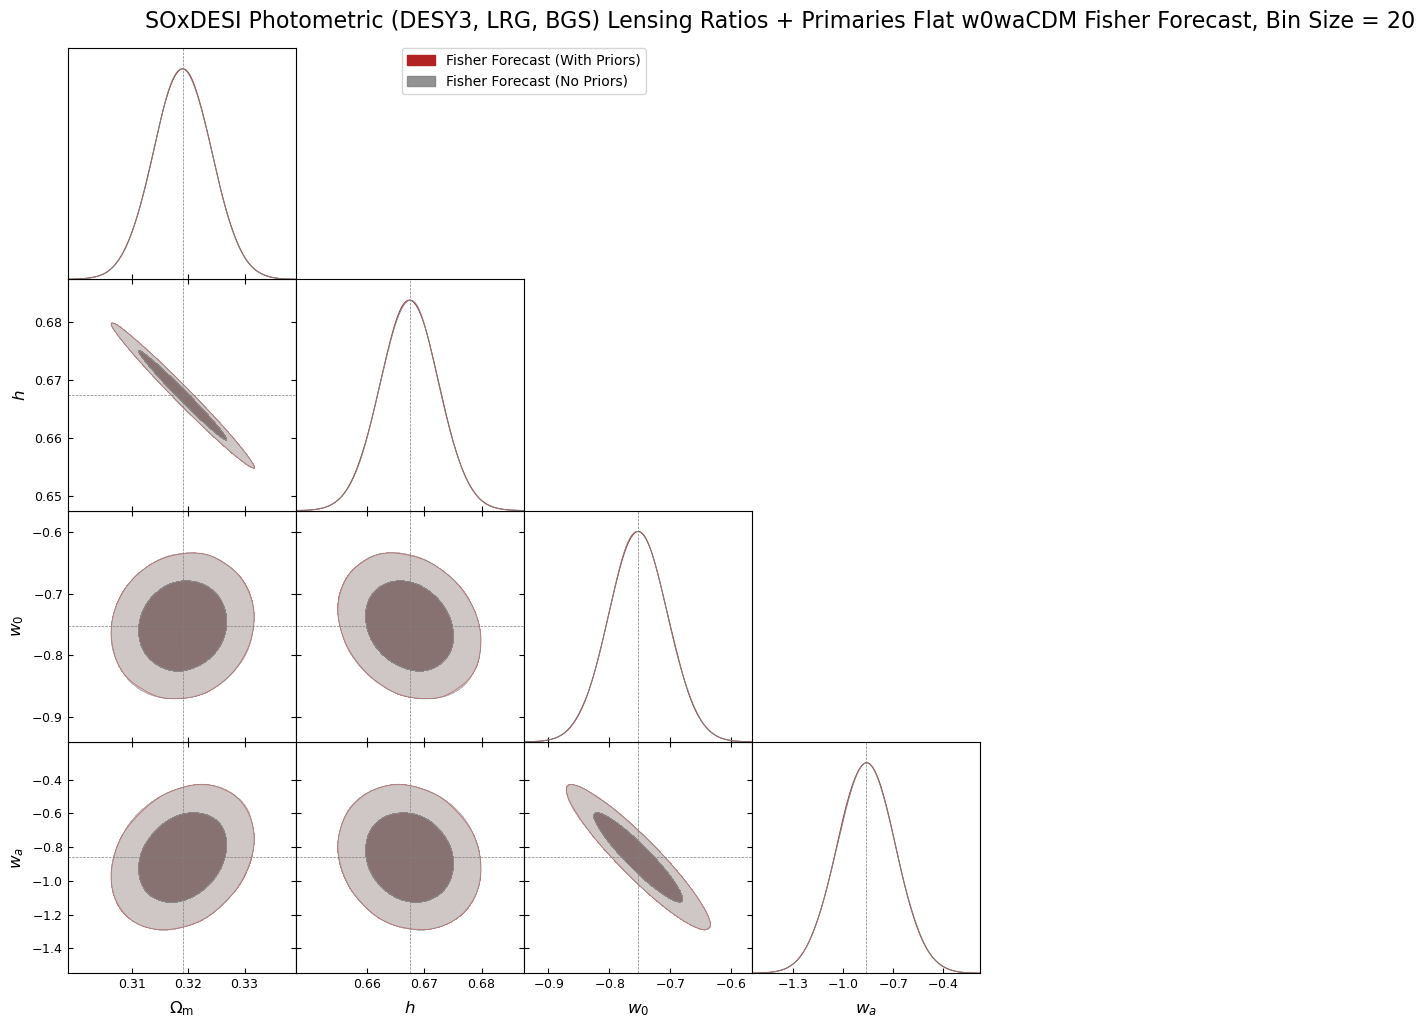

| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2676\pm 0.0044$ | $\Omega_{c} = 0.2676^{+0.0087}_{-0.0087}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2676\pm 0.0044$ | $\Omega_{c} = 0.2676^{+0.0086}_{-0.0087}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00076$ | $\Omega_{b} = 0.0499^{+0.0015}_{-0.0015}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00076$ | $\Omega_{b} = 0.0499^{+0.0015}_{-0.0015}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0051$ | $h = 0.667^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.095}_{-0.095}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.095}_{-0.095}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.18$ | $w_a = -0.86^{+0.34}_{-0.35}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.18$ | $w_a = -0.86^{+0.34}_{-0.34}$ |
| --- | --- | --- | --- |
| **$logA_s$** | Fisher Forecast (With Priors) | $logA_s = 3.0417\pm 0.0019$ | $logA_s = 3.0417^{+0.0037}_{-0.0037}$ |
|  | Fisher Forecast (No Priors) | $logA_s = 3.0417\pm 0.0019$ | $logA_s = 3.0417^{+0.0037}_{-0.0037}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9654\pm 0.0022$ | $n_s = 0.9654^{+0.0042}_{-0.0043}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9654\pm 0.0022$ | $n_s = 0.9654^{+0.0042}_{-0.0042}$ |
| --- | --- | --- | --- |

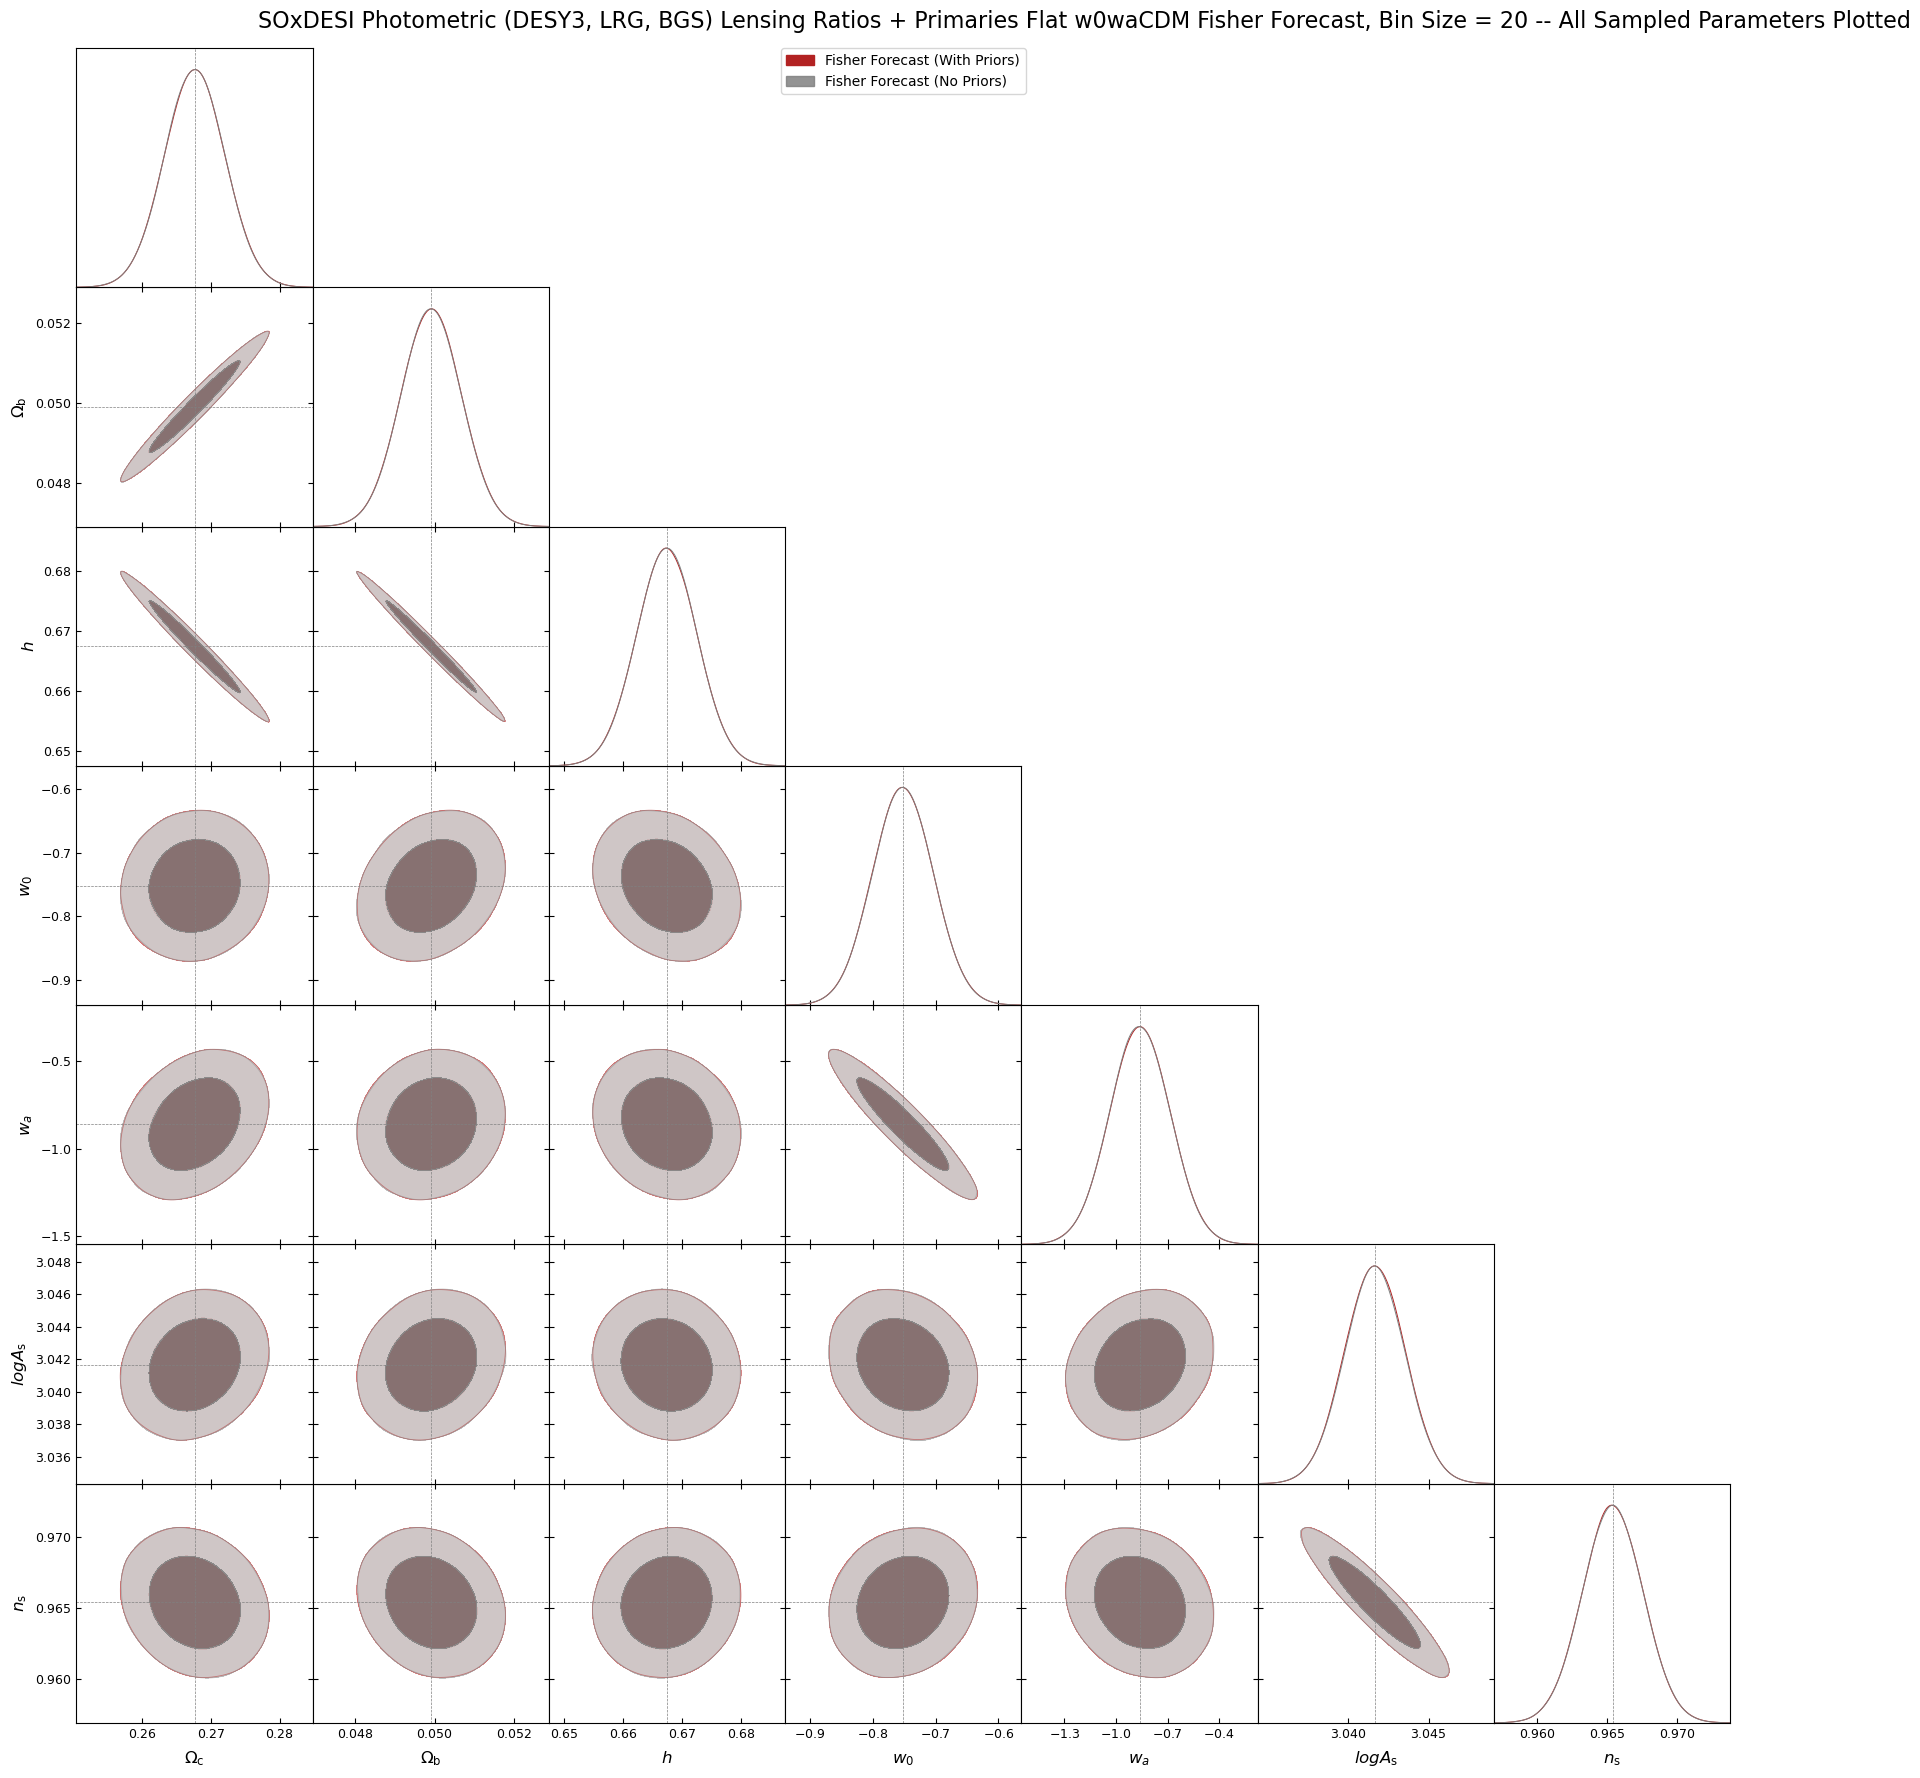

total_time:  0:05:51.649031


In [17]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE', 'TE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'logA_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=100_post_T_fix.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa logA_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, logA_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=100_post_T_fix.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa logA_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, logA_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

# MCMC

## Syntax

In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/flat_LCDM_LR_Photo_BGS_DES_bin1_bs50_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
CHAIN_DEST="chains/flat_LCDM_LR_Photo_BGS_DES_bin1_bs50_likelihood"
mkdir -p $CHAIN_DEST

for i in {0..3}; do
    cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt $CHAIN_DEST/chain_task_${i}.txt
    ln -sf chain_task_${i}.txt $CHAIN_DEST/cosmo_run.${i}.txt
done

# Copy the paramnames file so your plotting code works immediately
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/chain_task.paramnames
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/cosmo_run.paramnames

## Covariances and MCMCs

In [14]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin w/lensing ratios primaries

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

# extract other parameters directly, or hardcode them if they are constant for this generation step
l_min = 40
n_ell = 5000
binsize = 100
magnification_bias_lenses = 0.8

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        flat_LCDM_cosmology,
        BGS_distributions_bin1,
        DES_source_data_bin1,
        f_sky_c = 0.4,
        f_sky_g = 0.4,
        f_sky_l = 0.1,
        f_sky_c_g = 0.295,
        f_sky_c_l = 0.0306,
        f_sky_g_l = 0.0306,
        f_sky_c_g_l = 0.0306,
        l_min=l_min,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=BGS_shot_noise_bin1,
        shape_noise_source=DES_shape_noise_bin1,
        cmb_noise_kk=SO_cmb_noise_kk,
        cmb_noise_TT=SO_goal_cmb_noise_TT,
        cmb_noise_EE=SO_goal_cmb_noise_EE,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=['CG', 'GL'],
        linear_emulator=None,
        boost_emulator=None,
        cmb_primaries = True,
        z_max = 6,
        n_chi = 1024
    )

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# extract and flatten the fiducial data vector
observed_data_vector = build_data_vector(forecast_map = f_map, spectra_dict = fiducial_spectra_dict, n_ell = n_ell, binsize = binsize)

# Save to files
data_vector_filename = 'cobaya_data/flat_LCDM_LR_Photo_BGS_DES_bin1_data_vector_binsize_100.npy'
covariance_filename = 'cobaya_data/flat_LCDM_LR_Photo_BGS_DES_bin1_covariance_matrix_binsize_100.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)